# Gamma transmission plotter

Maggie Tseng  
Last updated: Oct 13, 2025

This notebook: (1) reproduces Henke's plots of gamma attenuation length as a function of photon energy, and (2) makes plots of gamma transmission as a function of photon energy. It also makes a third plot as a sanity check: transmission as a function of implantation depth, which should be exactly exponential.

Note that the text files provided by Henke must be slightly modified by hand to be used here: put two spaces (instead of comma + space) between the header labels in the second line.

Henke data at: https://henke.lbl.gov/optical_constants/atten2.html  
(enter material name/chem formula, density -1 to use tabulated values)

Transmission equation: fraction of surviving photons = exp(- dist traveled by photon / attentuation length given by Henke), which can be written: 
$$T = \exp(-x/ \ell)$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
## Everything material-dependent goes in this cell
## Materials tried so far: Al, C

material = "Aluminum"
filepath = "Henke_data/xray5827_Al.dat"

# material = "Carbon"
# filepath = "Henke_data/xray8553_C.dat"

# material = "Lead"
# filepath = "Henke_data/xray8068_Pb.dat"

df1 = pd.read_csv(filepath,header=1,sep="  ",engine="python")
# implantation_depth = 2 # in microns; this value is currently an estimate based on LISE++ 1D range plot
implantation_depth = 0.333 # in microns; this value is currently an estimate based on LISE++ 1D range plot

In [11]:
## List the dataframe columns, and rename them 'in place' (instead of copying the dataframe)
# list(df1)
df1.rename(columns={'Photon Energy (eV)': 'energy', 'Atten Length (microns)': 'attn_length'}, inplace=True)

## Here's one column:
# df1["energy"]

energy = df1["energy"]
attn_length = df1["attn_length"]

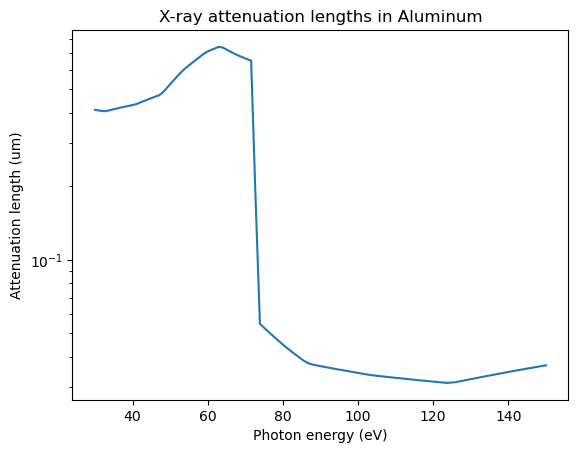

In [12]:
## This should be an exact reproduction of the plot that Henke website provides
## Plots attn length as func of energy

plt.xlabel("Photon energy (eV)")
plt.ylabel("Attenuation length (um)")
plt.title(f"X-ray attenuation lengths in {material}")

plt.yscale('log') # comment this out to make lin-lin plot instead
plt.plot(energy, attn_length)

In [13]:
## Now we'll calculate transmission and put it on a log-scale y axis
## Suppose that our implantation is 2 um deep in the material we previously chose
# implantation_depth = 2 # in microns; this value is material-dependent so I've moved its definition to second code cell
transmission = np.exp(-1 * implantation_depth / attn_length)

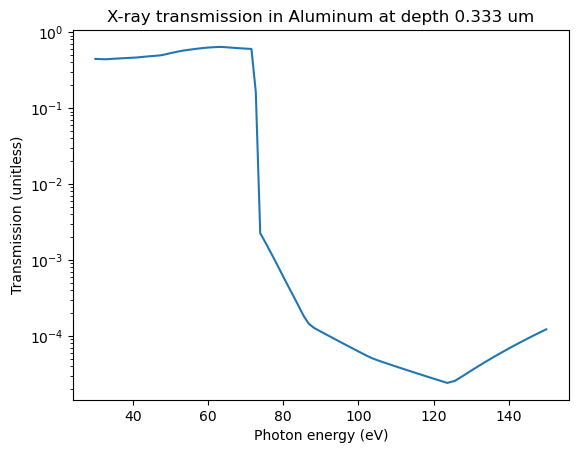

In [14]:
plt.xlabel("Photon energy (eV)")
plt.ylabel("Transmission (unitless)")
plt.title(f"X-ray transmission in {material} at depth {implantation_depth} um")

## force y axis to include 1 (ie 100%) as well as min transmission, with some spacing to look better
# plt.axis(
#     ymax=1,
#     ymin= np.min(transmission)/10
# )
plt.yscale('log') # comment this out to make lin-lin plot instead
plt.plot(energy, transmission)

In [7]:
## What if we vary implantation depth instead?

## Make an array of 100 implantation depths across some reasonable range, like 0 to 5 microns
## (or define that reasonable range using the implantation depth that we defined earlier)
depths = np.linspace(0,3*implantation_depth,100)

In [8]:
## Fix gamma energy at 60 eV, then (linearly) interpolate Henke data at that energy to get one particular attn length

index60 = np.searchsorted(energy,60)
m = (attn_length[index60] - attn_length[index60-1])/(energy[index60] - energy[index60-1])
attnlength_60 = m * (60 - energy[index60]) + attn_length[index60]
# print(attnlength_60)

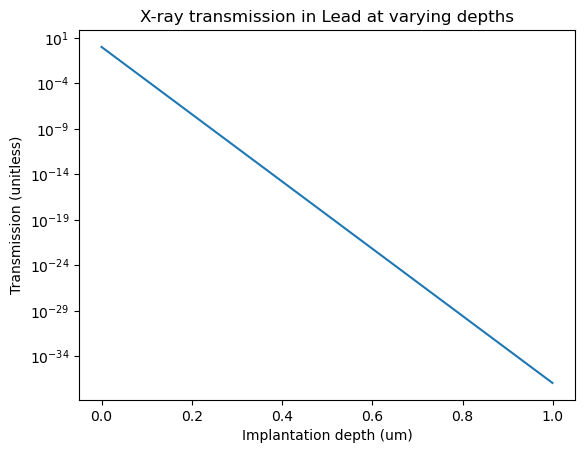

In [9]:
## Calculate transmission of different implantation depths, and plot.
## Just as we expect, this plot is exactly exponential. Its slope is material-dependent.
transmission2 = np.exp(-1 * depths / attnlength_60)

plt.xlabel("Implantation depth (um)")
plt.ylabel("Transmission (unitless)")
plt.title(f"X-ray transmission in {material} at varying depths")
plt.yscale('log')
plt.plot(depths, transmission2)

Transmission of 60 eV photons is a lot better in aluminum than in carbon. At 2 um implantation depth, the transmission through carbon is ~1e-12 % and the transmission through aluminum is ~1%.